# 🫘 Mini Project: Dry Bean Type Classification

**Student:** Vineeth Muraleedharan  
**Program:** Applied Data Science, ML & AI - E&ICT Academy, IIT Guwahati  
**Dataset:** Dry Bean Dataset (Camera-based Computer Vision)  
**Objective:** Multiclass classification of 7 dry bean types using supervised ML

---

## 📋 Project Overview

An agriculture company wants to automate dry bean classification using AI. We build an ML pipeline to classify beans based on 16 physical features into 7 categories:

> **SEKER | BARBUNYA | BOMBAY | CALI | DERMASON | HOROZ | SIRA**

---

## Step 1: Import Libraries & Load Data

In [8]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, ConfusionMatrixDisplay)

# Class Imbalance
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

In [9]:
# Load dataset
df = pd.read_excel('Dry_Bean_Dataset.xlsx')

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

print('\nMissing Values:')
print(df.isnull().sum())

(13611, 17)
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358    

---
## Step 2: Exploratory Data Analysis (EDA)

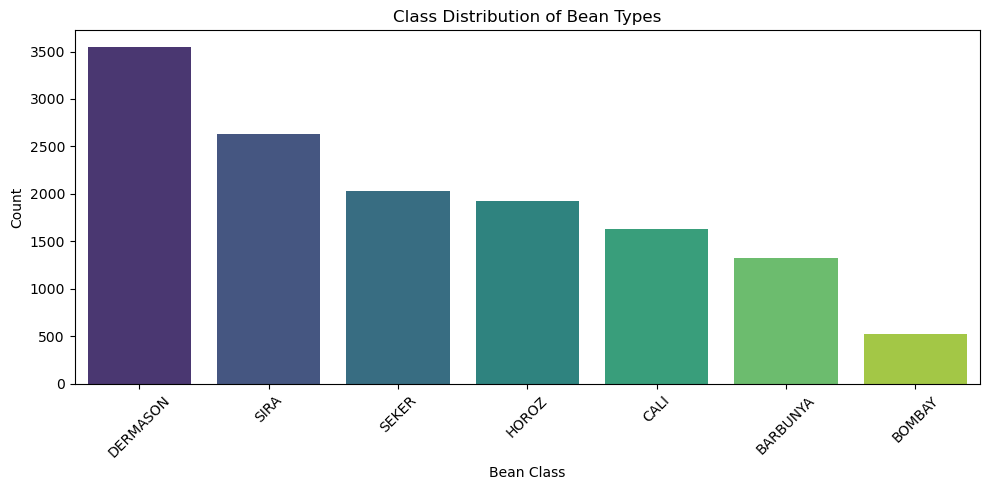

Class Distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Class Percentage:
Class
DERMASON    26.05%
SIRA        19.37%
SEKER       14.89%
HOROZ       14.17%
CALI        11.98%
BARBUNYA     9.71%
BOMBAY       3.84%
Name: proportion, dtype: object


In [10]:
# 2.1 - Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='Class', data=df, palette='viridis', order=df['Class'].value_counts().index)
plt.title('Class Distribution of Bean Types')
plt.xlabel('Bean Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Class Distribution:')
print(df['Class'].value_counts())
print('\nClass Percentage:')
print(df['Class'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

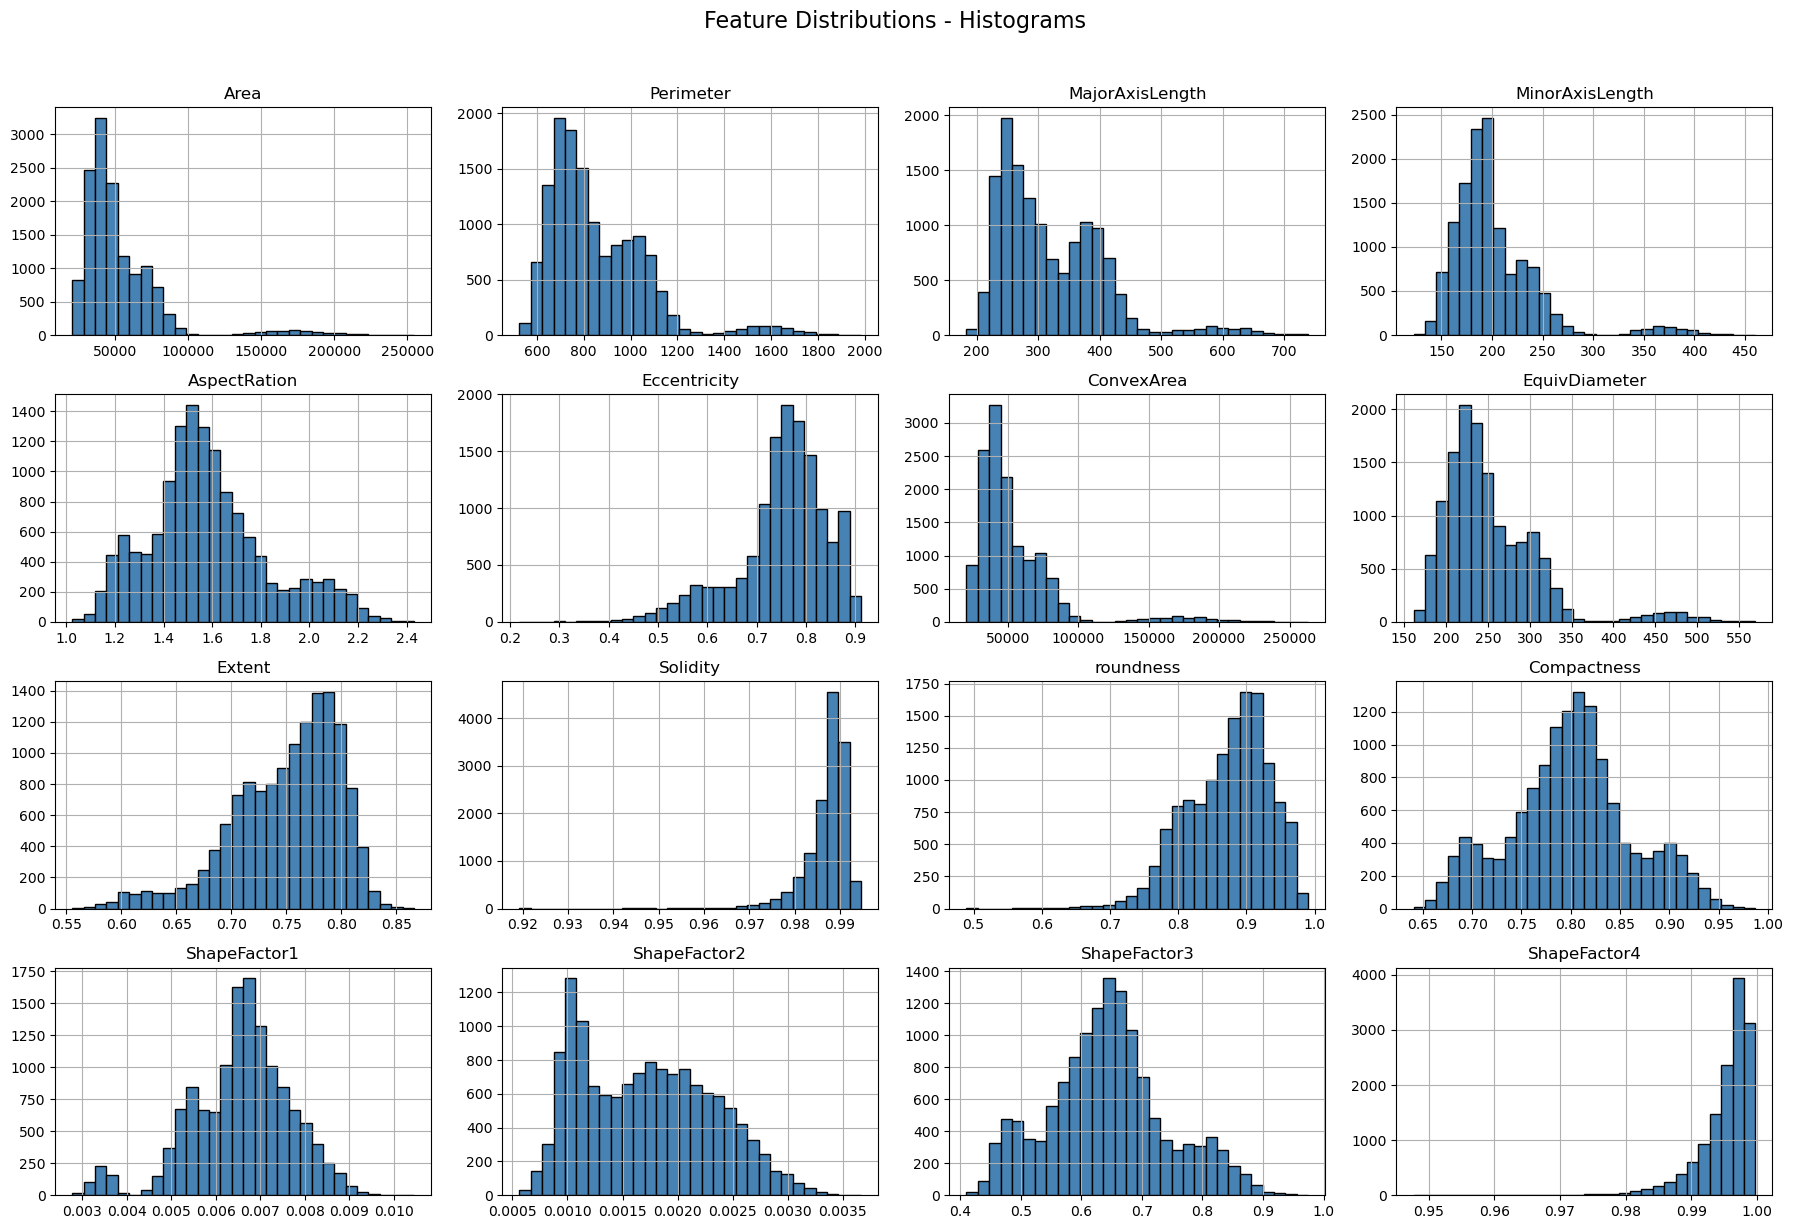

In [11]:
# 2.2 - Histograms
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(figsize=(18, 12), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions - Histograms', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

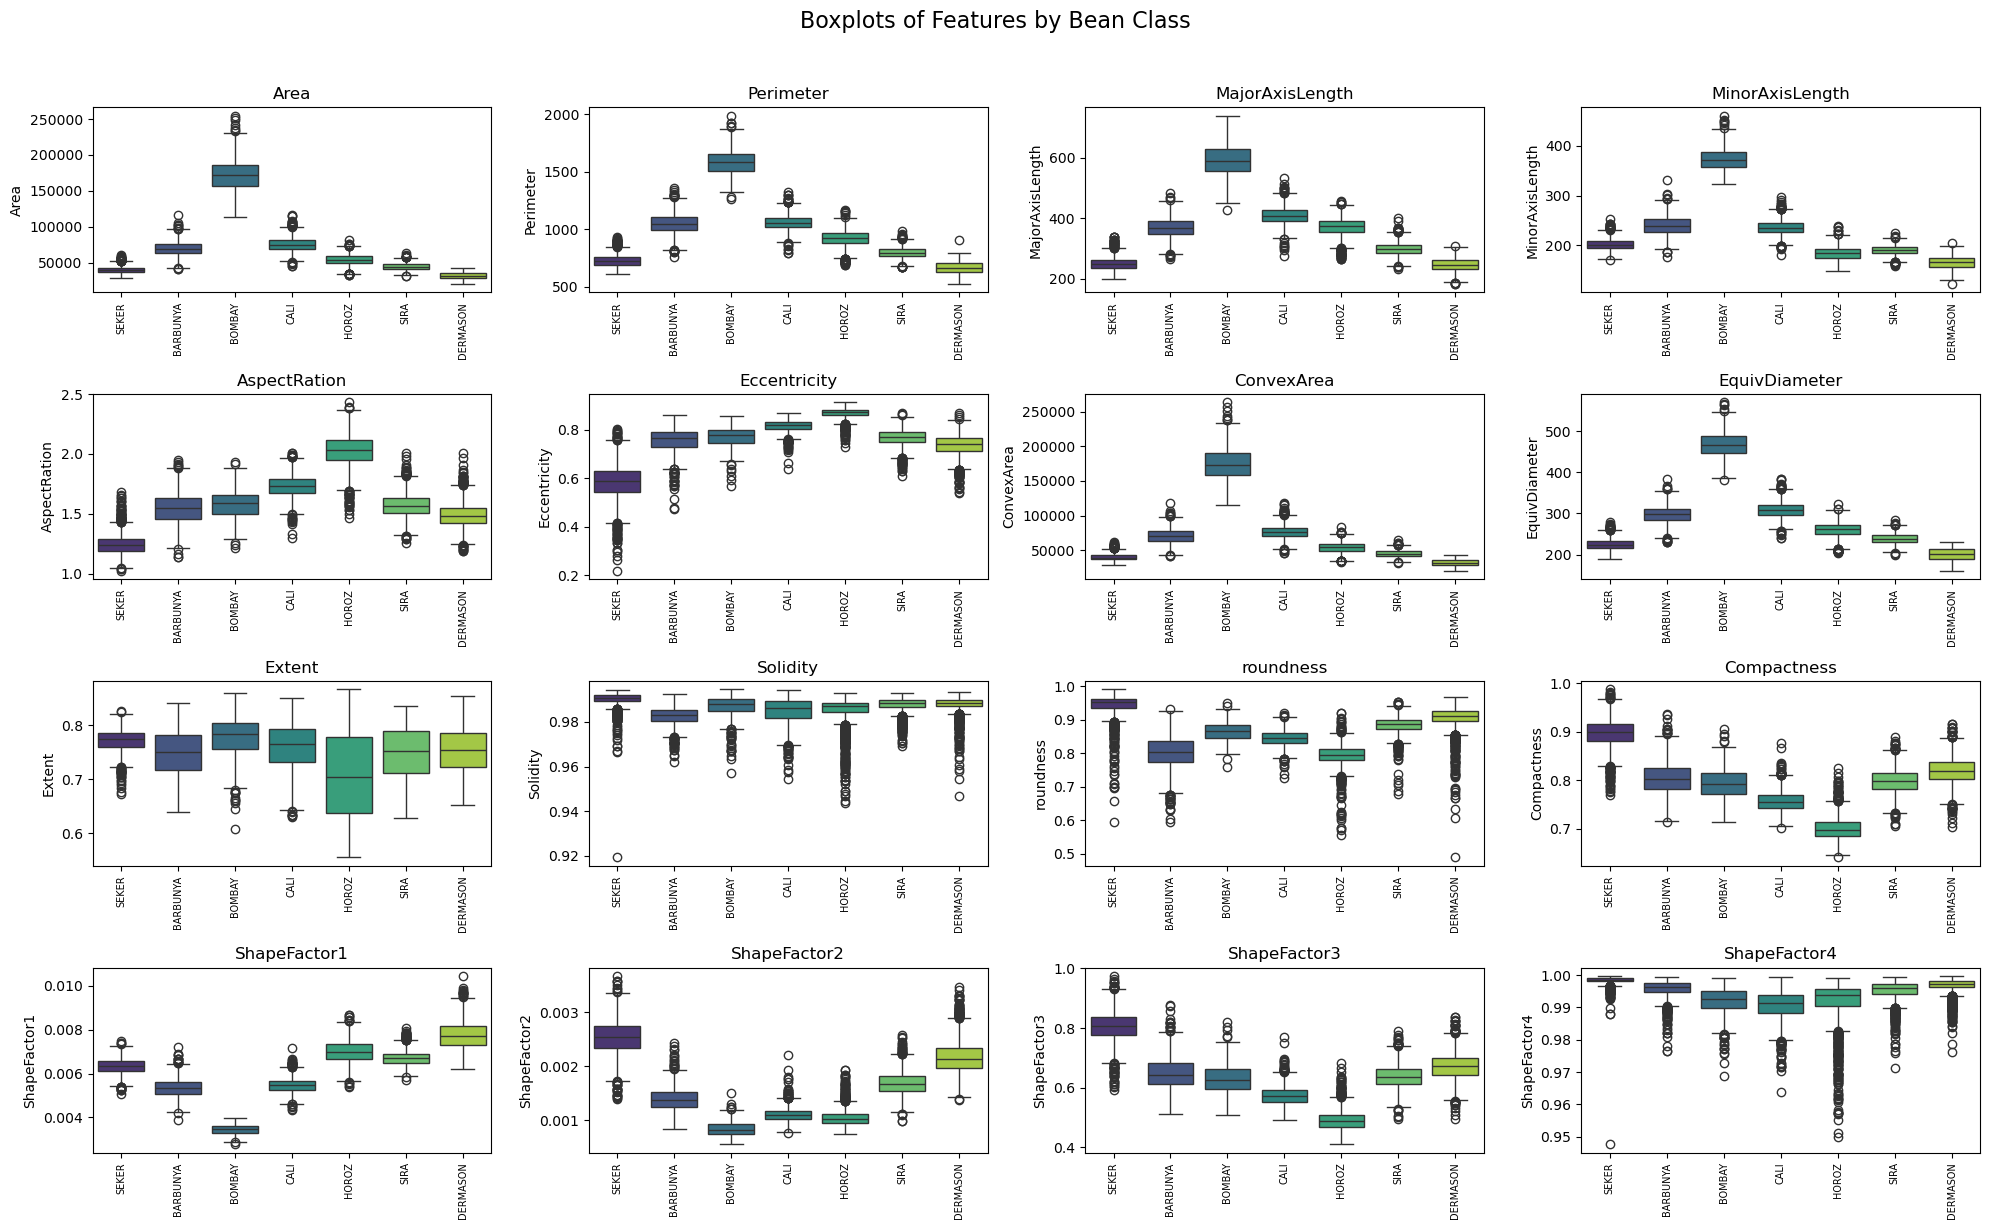

In [12]:
# 2.3 - Boxplots by Class
plt.figure(figsize=(20, 12))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x='Class', y=col, data=df, palette='viridis')
    plt.title(col)
    plt.xticks(rotation=90, fontsize=7)
    plt.xlabel('')
plt.suptitle('Boxplots of Features by Bean Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

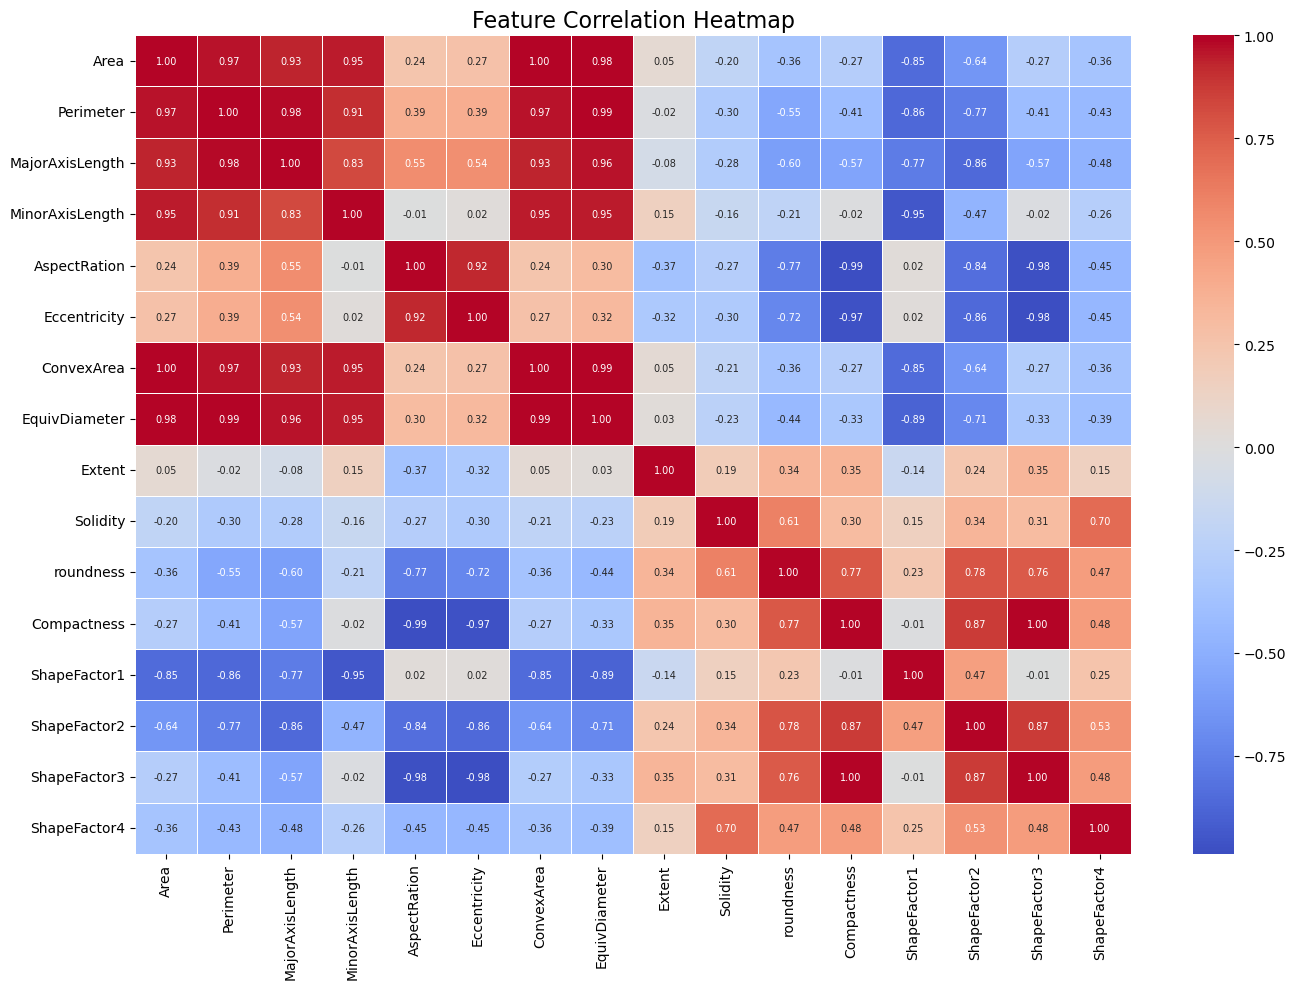

In [13]:
# 2.4 - Correlation Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

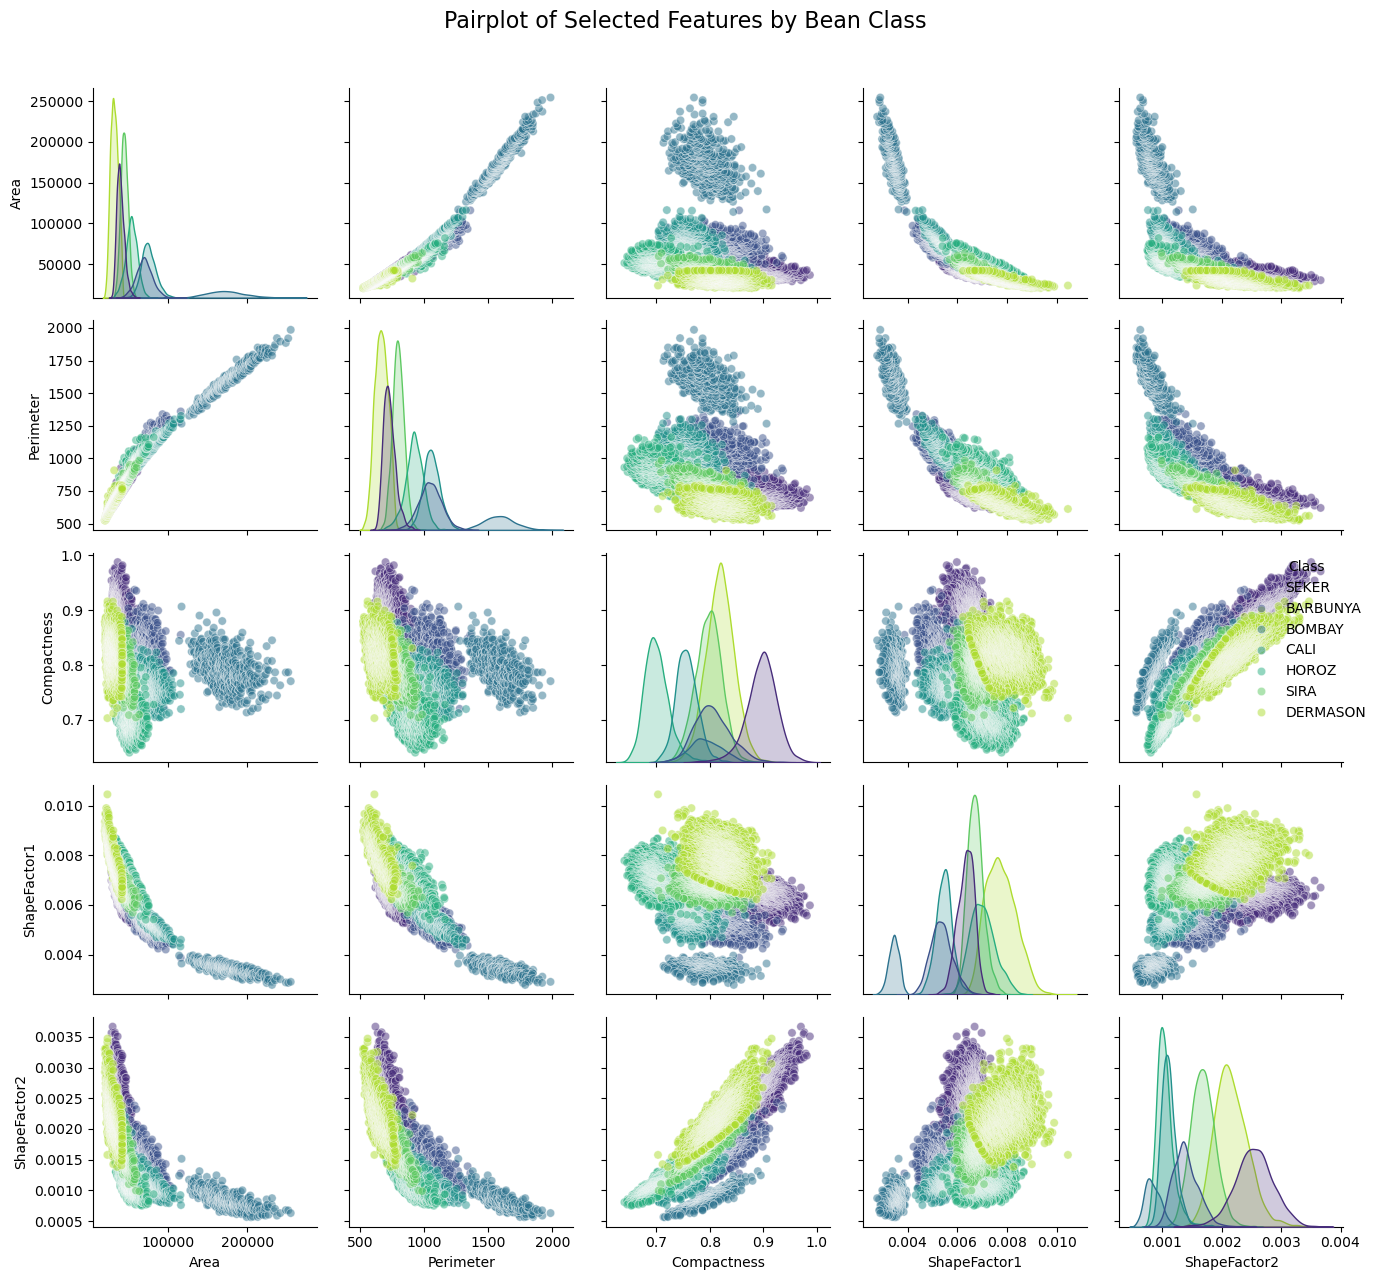

In [14]:
# 2.5 - Pairplot
selected_features = ['Area', 'Perimeter', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'Class']
sns.pairplot(df[selected_features], hue='Class', palette='viridis',
             diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Selected Features by Bean Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# 2.6 - Key Findings
print("""
KEY FINDINGS

1. DATASET OVERVIEW:
   - Total samples  : {}
   - Total features : {}
   - Target classes : {}

2. CLASS DISTRIBUTION:
   - DERMASON & SIRA are majority classes
   - BOMBAY is the minority class
   - Needs SMOTE in Step 6

3. FEATURE DISTRIBUTIONS:
   - Size features are right-skewed -> need scaling
   - Shape features are relatively normal

4. OUTLIERS:
   - Present in size-based features -> treated in Step 3

5. CORRELATIONS:
   - High multicollinearity among size features
   - May impact Logistic Regression & SVM

6. CLASS SEPARABILITY:
   - BOMBAY is most distinctly separable
   - DERMASON, CALI, HOROZ overlap significantly
   - ShapeFactor1 & ShapeFactor2 show good separation
""".format(df.shape[0], df.shape[1]-1, df['Class'].nunique()))


KEY FINDINGS

1. DATASET OVERVIEW:
   - Total samples  : 13611
   - Total features : 16
   - Target classes : 7

2. CLASS DISTRIBUTION:
   - DERMASON & SIRA are majority classes
   - BOMBAY is the minority class
   - Needs SMOTE in Step 6

3. FEATURE DISTRIBUTIONS:
   - Size features are right-skewed -> need scaling
   - Shape features are relatively normal

4. OUTLIERS:
   - Present in size-based features -> treated in Step 3

5. CORRELATIONS:
   - High multicollinearity among size features
   - May impact Logistic Regression & SVM

6. CLASS SEPARABILITY:
   - BOMBAY is most distinctly separable
   - DERMASON, CALI, HOROZ overlap significantly
   - ShapeFactor1 & ShapeFactor2 show good separation



### 📊 EDA Summary

- **Dataset:** 13,611 samples x 16 features -> 7 bean classes
- **Class Imbalance:** DERMASON & SIRA dominate; BOMBAY is minority class
- **Feature Distributions:** Size-based features are right-skewed -> require scaling
- **Outliers:** Present in size-based features -> treated in Step 3
- **Multicollinearity:** High correlation (>0.95) among Area, Perimeter, ConvexArea & EquivDiameter
- **Best Separating Features:** ShapeFactor1, ShapeFactor2 & Compactness

---

## Step 3: Missing Values & Outlier Treatment

In [16]:
# 3.1 - Missing Values
print('Missing Values per Feature:')
print(df.isnull().sum())
print(f'\nTotal Missing Values: {df.isnull().sum().sum()}')

Missing Values per Feature:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Total Missing Values: 0


In [17]:
# 3.2 - IQR Outlier Detection
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
outlier_df['Outlier %'] = (outlier_df['Outlier Count'] / len(df) * 100).round(2)
print('Outlier Detection - IQR Method:')
print(outlier_df.sort_values('Outlier Count', ascending=False))

Outlier Detection - IQR Method:
                 Outlier Count  Outlier %
Eccentricity               843       6.19
Solidity                   778       5.72
ShapeFactor4               767       5.64
MinorAxisLength            569       4.18
Area                       551       4.05
ConvexArea                 550       4.04
ShapeFactor1               533       3.92
EquivDiameter              526       3.86
Perimeter                  500       3.67
AspectRation               473       3.48
MajorAxisLength            379       2.78
Extent                     275       2.02
ShapeFactor3               195       1.43
Compactness                109       0.80
roundness                   91       0.67
ShapeFactor2                 0       0.00


In [18]:
# 3.3 - Z-Score Outlier Detection
from scipy import stats
z_outlier_summary = {}
for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    z_outlier_summary[col] = len(df[z_scores > 3])

z_outlier_df = pd.DataFrame.from_dict(z_outlier_summary, orient='index', columns=['Outlier Count'])
z_outlier_df['Outlier %'] = (z_outlier_df['Outlier Count'] / len(df) * 100).round(2)
print('Outlier Detection - Z-Score Method (threshold=3):')
print(z_outlier_df.sort_values('Outlier Count', ascending=False))

Outlier Detection - Z-Score Method (threshold=3):
                 Outlier Count  Outlier %
MinorAxisLength            508       3.73
Area                       483       3.55
ConvexArea                 483       3.55
EquivDiameter              465       3.42
Perimeter                  404       2.97
MajorAxisLength            316       2.32
ShapeFactor4               242       1.78
Solidity                   238       1.75
Extent                     135       0.99
Eccentricity               125       0.92
roundness                   74       0.54
ShapeFactor1                59       0.43
AspectRation                15       0.11
ShapeFactor3                 8       0.06
ShapeFactor2                 5       0.04
Compactness                  1       0.01


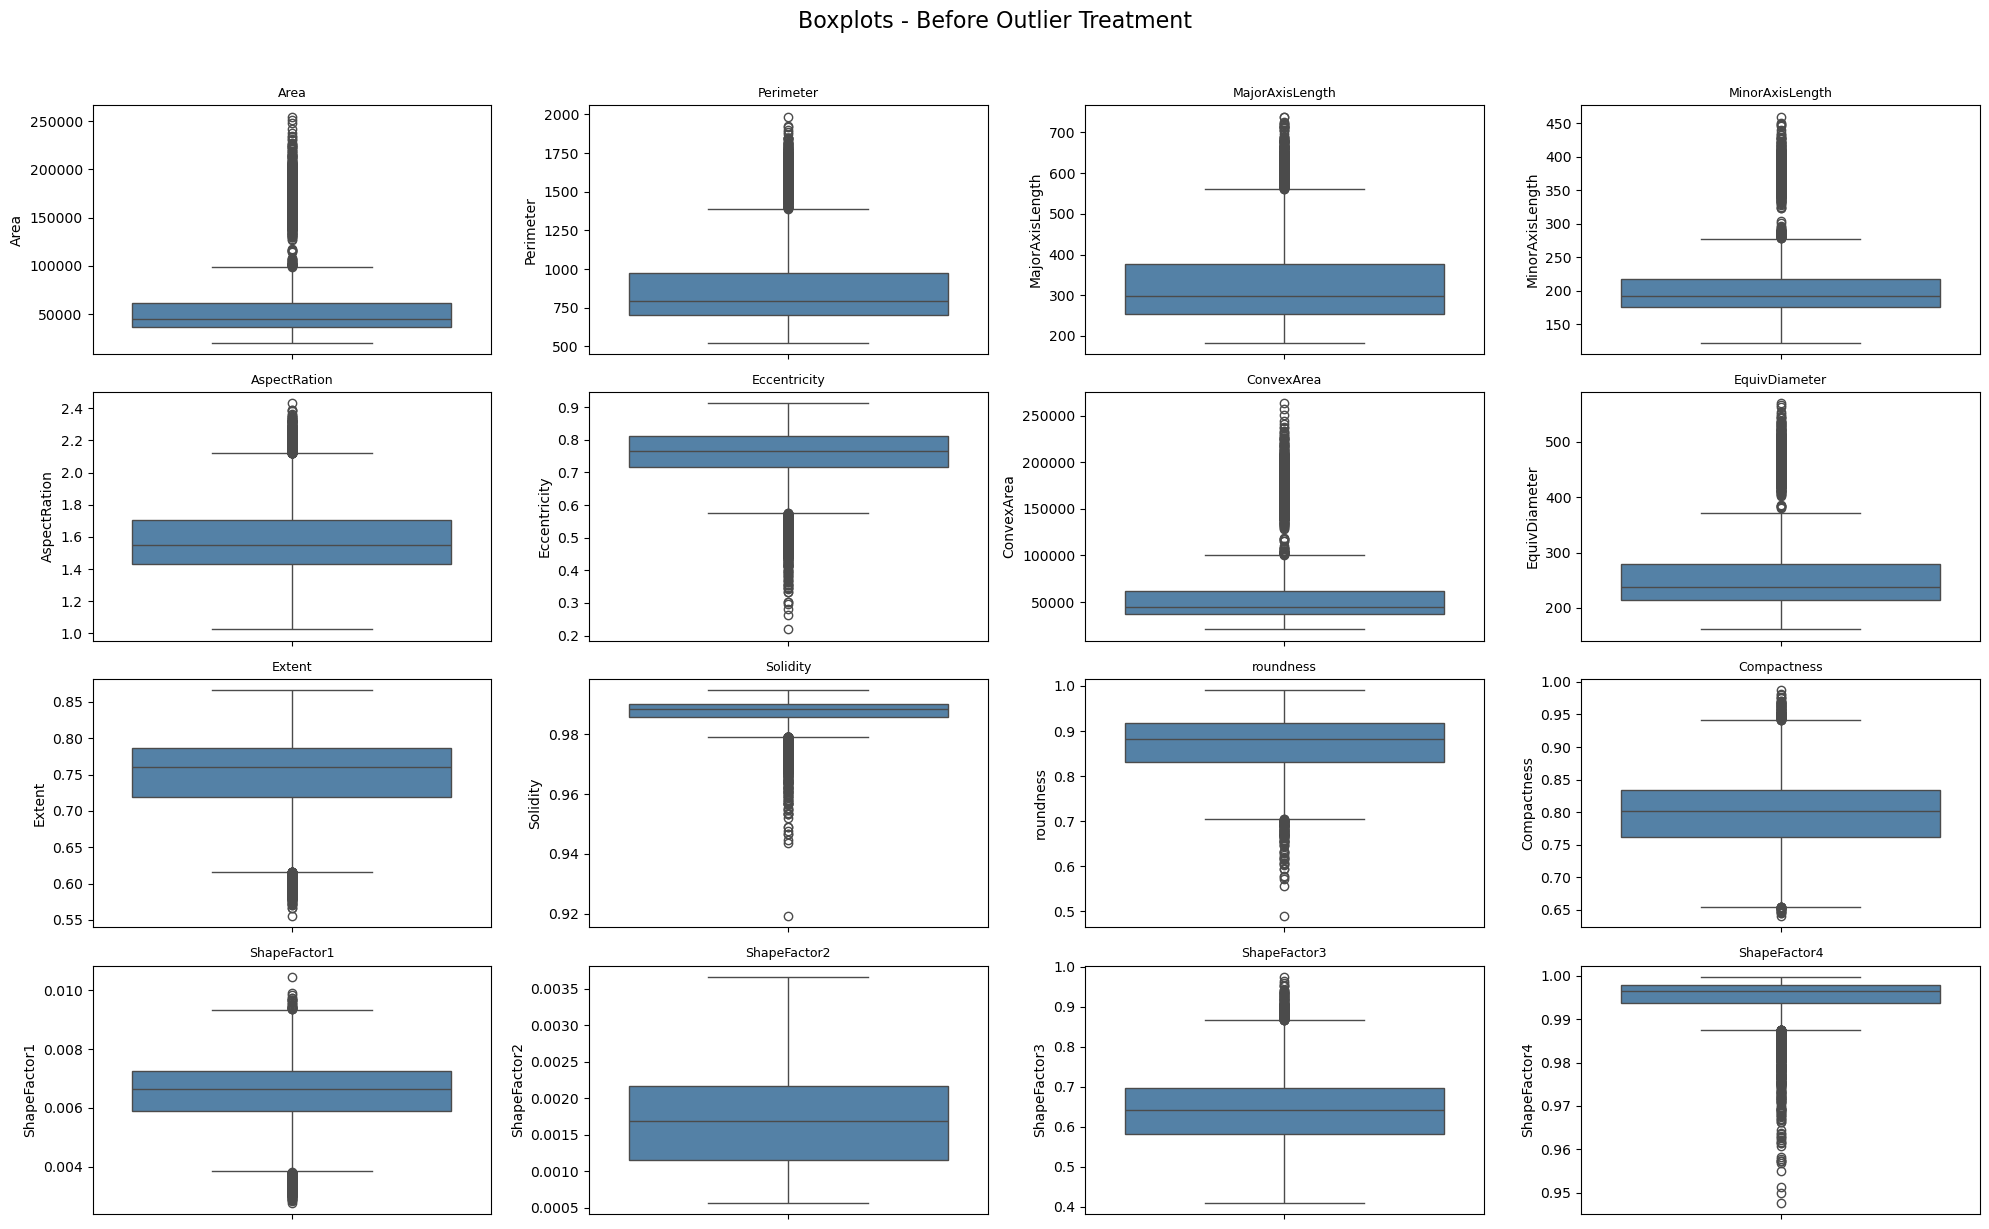

In [19]:
# 3.3b - Boxplots Before Treatment
plt.figure(figsize=(20, 12))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col], color='steelblue')
    plt.title(col, fontsize=9)
plt.suptitle('Boxplots - Before Outlier Treatment', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Shape before: (13611, 17)
Shape after : (13611, 17)


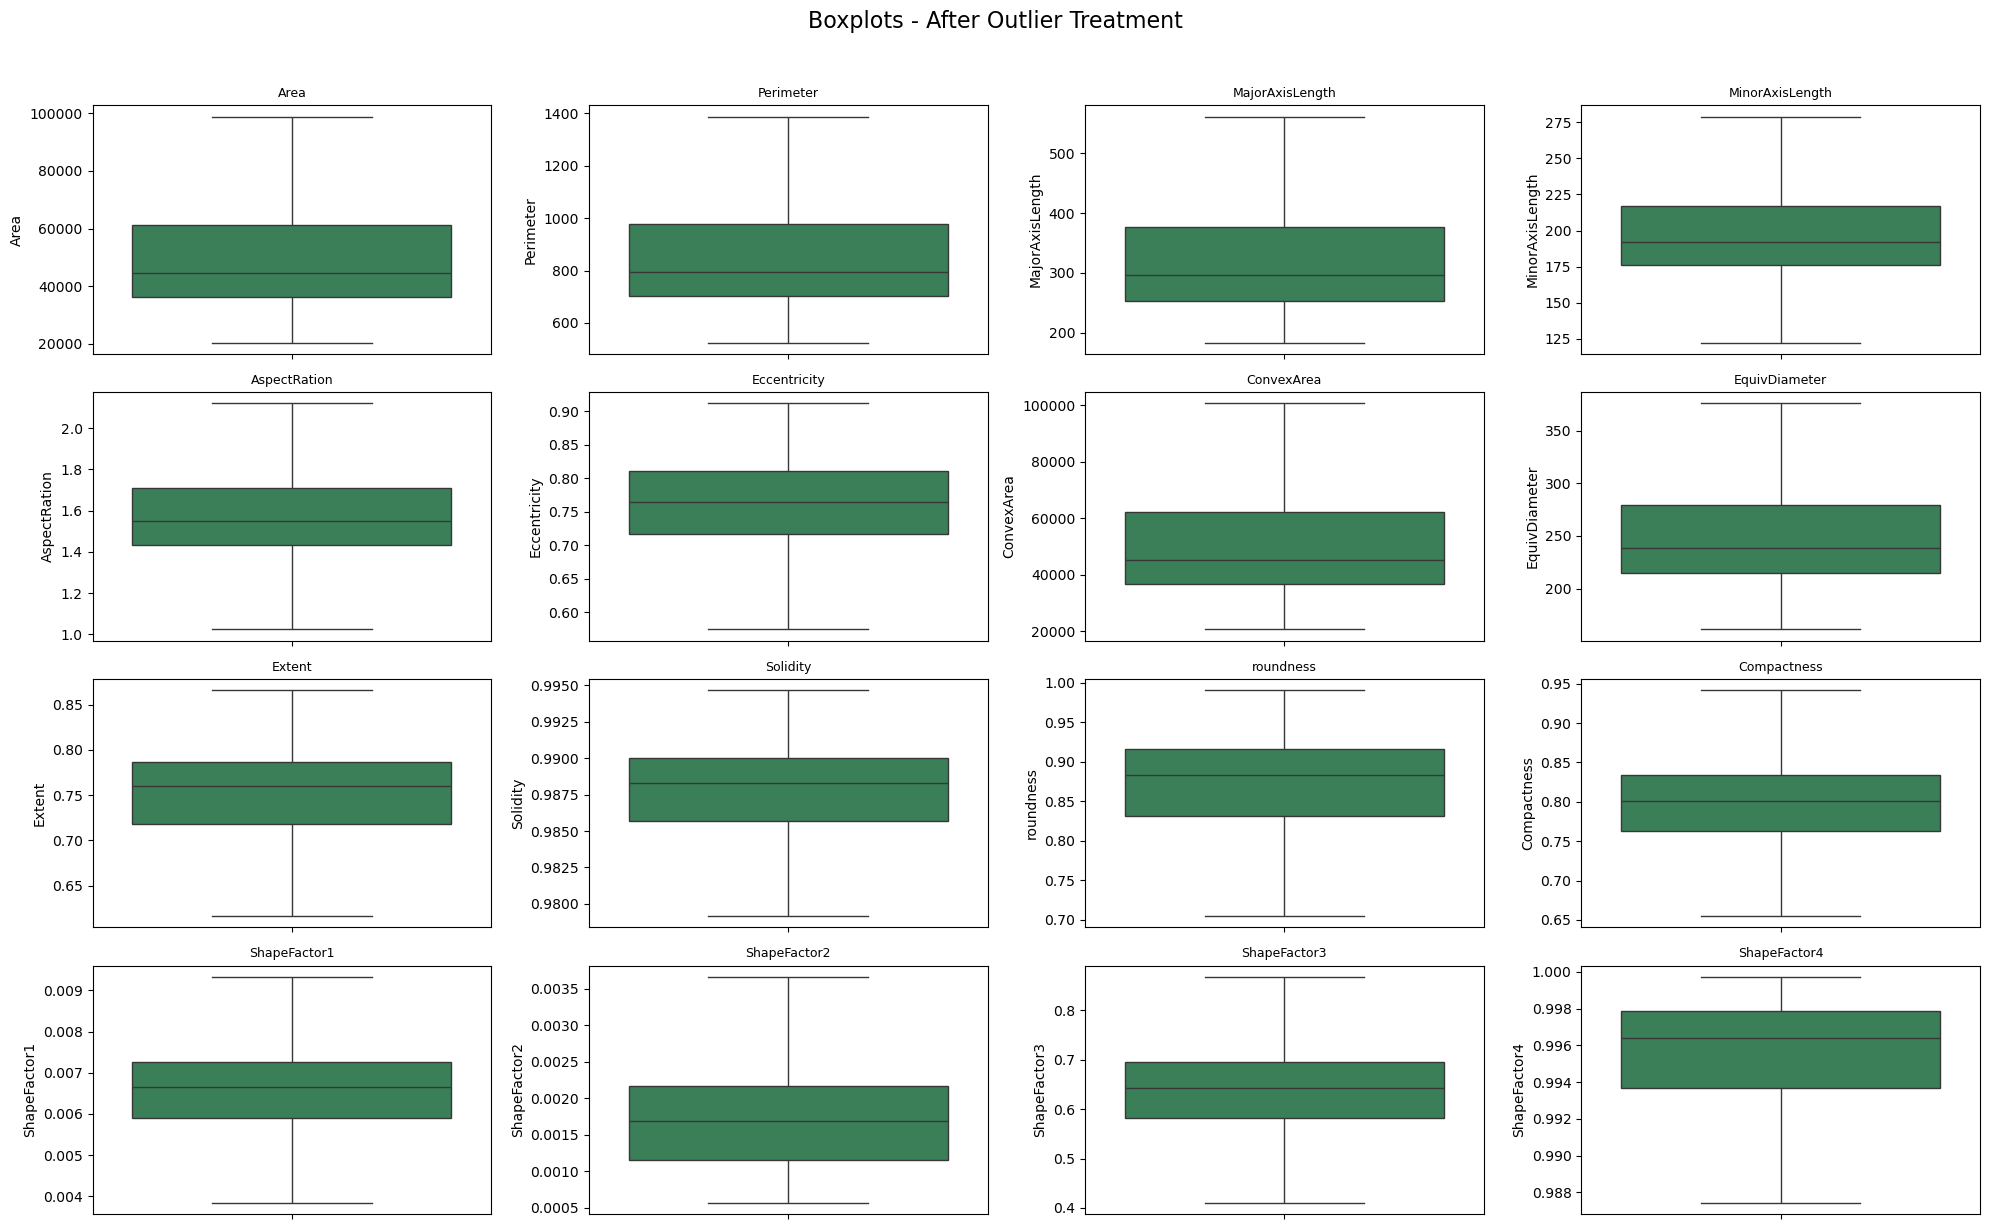

In [20]:
# 3.4 - Winsorization
df_treated = df.copy()
for col in num_cols:
    Q1 = df_treated[col].quantile(0.25)
    Q3 = df_treated[col].quantile(0.75)
    IQR = Q3 - Q1
    df_treated[col] = df_treated[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print(f'Shape before: {df.shape}')
print(f'Shape after : {df_treated.shape}')

# Boxplots After
plt.figure(figsize=(20, 12))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df_treated[col], color='seagreen')
    plt.title(col, fontsize=9)
plt.suptitle('Boxplots - After Outlier Treatment', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 4: Feature Engineering & Preprocessing

Skewness:
MajorAxisLength    0.971004
ConvexArea         0.963532
Perimeter          0.961668
Area               0.956989
EquivDiameter      0.832987
MinorAxisLength    0.727810
AspectRation       0.472940
ShapeFactor2       0.301226
ShapeFactor3       0.193072
Compactness        0.018794
ShapeFactor1      -0.329187
roundness         -0.492208
Eccentricity      -0.610125
Extent            -0.783295
Solidity          -0.844704
ShapeFactor4      -1.040172
dtype: float64


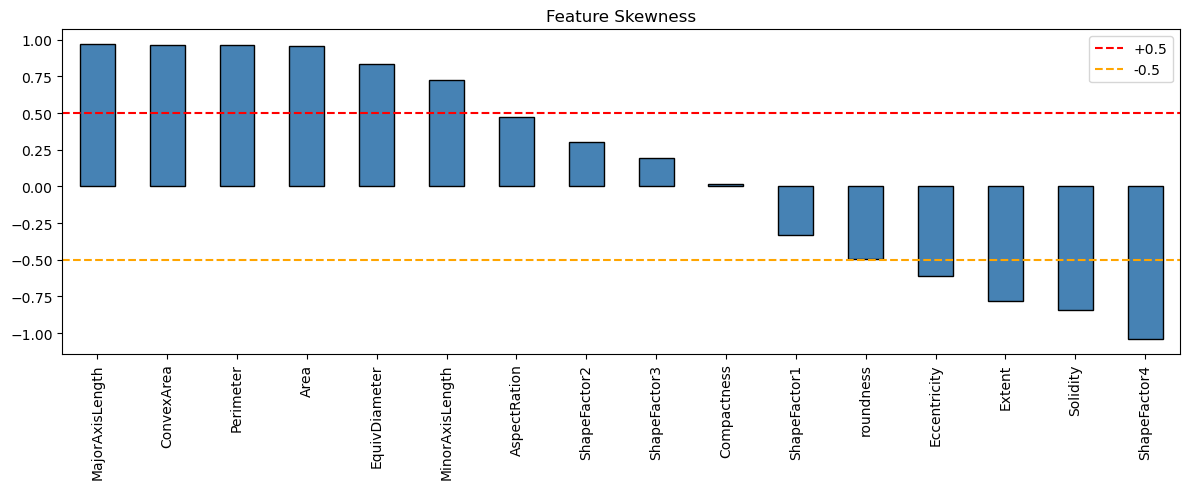

In [21]:
# 4.1 - Skewness Check
skewness = df_treated[num_cols].skew().sort_values(ascending=False)
print('Skewness:')
print(skewness)

plt.figure(figsize=(12, 5))
skewness.plot(kind='bar', color='steelblue', edgecolor='black')
plt.axhline(y=0.5,  color='red',    linestyle='--', label='+0.5')
plt.axhline(y=-0.5, color='orange', linestyle='--', label='-0.5')
plt.title('Feature Skewness')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# 4.2 - Log Transformation
skewed_features = skewness[abs(skewness) > 0.5].index.tolist()
print(f'Skewed Features: {skewed_features}')
df_treated[skewed_features] = df_treated[skewed_features].apply(lambda x: np.log1p(x))
print('\nSkewness After Treatment:')
print(df_treated[num_cols].skew().sort_values(ascending=False))

Skewed Features: ['MajorAxisLength', 'ConvexArea', 'Perimeter', 'Area', 'EquivDiameter', 'MinorAxisLength', 'Eccentricity', 'Extent', 'Solidity', 'ShapeFactor4']

Skewness After Treatment:
Perimeter          0.512103
AspectRation       0.472940
MajorAxisLength    0.467097
EquivDiameter      0.445156
MinorAxisLength    0.377734
ConvexArea         0.332407
Area               0.325111
ShapeFactor2       0.301226
ShapeFactor3       0.193072
Compactness        0.018794
ShapeFactor1      -0.329187
roundness         -0.492208
Eccentricity      -0.714114
Solidity          -0.848154
Extent            -0.850560
ShapeFactor4      -1.042810
dtype: float64


In [23]:
# 4.3 - Label Encoding
le = LabelEncoder()
df_treated['Class_encoded'] = le.fit_transform(df_treated['Class'])
print('Class Encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} -> {i}')

Class Encoding:
  BARBUNYA -> 0
  BOMBAY -> 1
  CALI -> 2
  DERMASON -> 3
  HOROZ -> 4
  SEKER -> 5
  SIRA -> 6


In [24]:
# 4.4 - StandardScaler
X = df_treated[num_cols]
y = df_treated['Class_encoded']

scaler  = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=num_cols)
print('Scaling Complete')
print(X_scaled.describe().loc[['mean', 'std']].round(2))

Scaling Complete
      Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
mean  -0.0       -0.0              0.0             -0.0          -0.0   
std    1.0        1.0              1.0              1.0           1.0   

      Eccentricity  ConvexArea  EquivDiameter  Extent  Solidity  roundness  \
mean          -0.0         0.0           -0.0    -0.0       0.0        0.0   
std            1.0         1.0            1.0     1.0       1.0        1.0   

      Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  
mean         -0.0           0.0           0.0          -0.0          -0.0  
std           1.0           1.0           1.0           1.0           1.0  


In [25]:
# 4.5 - Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training Set : {X_train.shape}')
print(f'Testing Set  : {X_test.shape}')
print('\nClass Distribution in Training Set:')
for i, count in pd.Series(y_train).value_counts().sort_index().items():
    print(f'  {le.classes_[i]:<12} -> {count}')

Training Set : (10888, 16)
Testing Set  : (2723, 16)

Class Distribution in Training Set:
  BARBUNYA     -> 1057
  BOMBAY       -> 418
  CALI         -> 1304
  DERMASON     -> 2837
  HOROZ        -> 1542
  SEKER        -> 1621
  SIRA         -> 2109


---
## Step 5: Model Building - Multiple Classifiers

In [26]:
# 5.1 - Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr    = lr.predict(X_test)
train_acc_lr = lr.score(X_train, y_train)
test_acc_lr  = accuracy_score(y_test, y_pred_lr)
f1_lr        = f1_score(y_test, y_pred_lr, average='weighted')
cv_scores_lr = cross_val_score(lr, X_scaled, y, cv=5)

print('LOGISTIC REGRESSION')
print(f'Train: {train_acc_lr:.4f} | Test: {test_acc_lr:.4f} | F1: {f1_lr:.4f} | CV: {cv_scores_lr.mean():.4f}')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

LOGISTIC REGRESSION
Train: 0.9259 | Test: 0.9247 | F1: 0.9248 | CV: 0.8480
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.86      0.89      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.92      0.92      2723



In [27]:
# 5.2 - Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt    = dt.predict(X_test)
train_acc_dt = dt.score(X_train, y_train)
test_acc_dt  = accuracy_score(y_test, y_pred_dt)
f1_dt        = f1_score(y_test, y_pred_dt, average='weighted')
cv_scores_dt = cross_val_score(dt, X_scaled, y, cv=5)

print('DECISION TREE')
print(f'Train: {train_acc_dt:.4f} | Test: {test_acc_dt:.4f} | F1: {f1_dt:.4f} | CV: {cv_scores_dt.mean():.4f}')
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

DECISION TREE
Train: 1.0000 | Test: 0.8931 | F1: 0.8928 | CV: 0.5557
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.90      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.92      0.92       326
    DERMASON       0.89      0.89      0.89       709
       HOROZ       0.93      0.93      0.93       386
       SEKER       0.91      0.95      0.93       406
        SIRA       0.82      0.80      0.81       527

    accuracy                           0.89      2723
   macro avg       0.91      0.91      0.91      2723
weighted avg       0.89      0.89      0.89      2723



RANDOM FOREST
Train: 1.0000 | Test: 0.9225 | F1: 0.9225 | CV: 0.6052
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



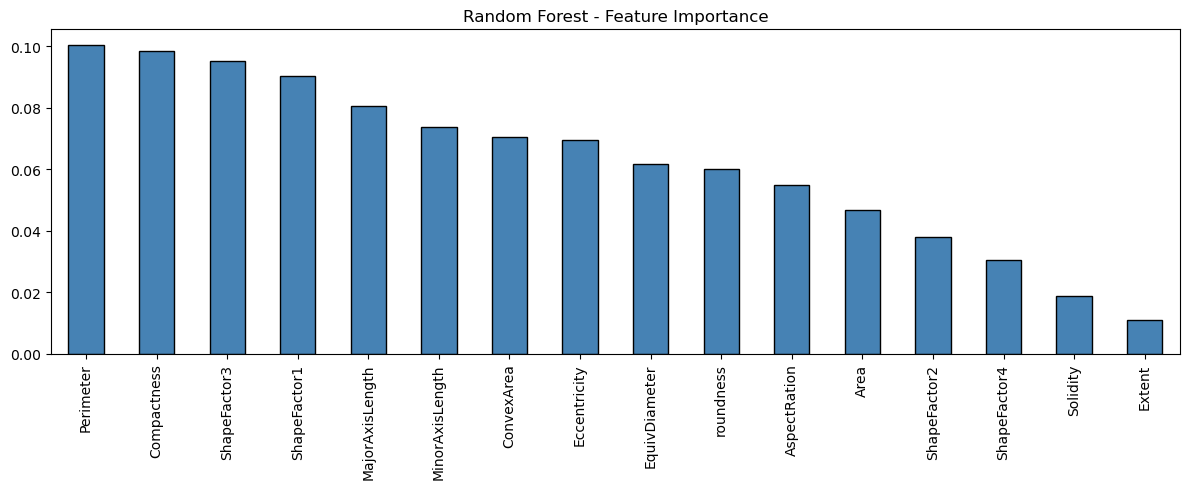

In [28]:
# 5.3 - Random Forest + Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf    = rf.predict(X_test)
train_acc_rf = rf.score(X_train, y_train)
test_acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_rf        = f1_score(y_test, y_pred_rf, average='weighted')
cv_scores_rf = cross_val_score(rf, X_scaled, y, cv=5)

print('RANDOM FOREST')
print(f'Train: {train_acc_rf:.4f} | Test: {test_acc_rf:.4f} | F1: {f1_rf:.4f} | CV: {cv_scores_rf.mean():.4f}')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

plt.figure(figsize=(12, 5))
pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False).plot(
    kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

KNN
Train: 0.9422 | Test: 0.9144 | F1: 0.9145 | CV: 0.8396
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.87      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.95      0.93       326
    DERMASON       0.90      0.91      0.90       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.95      0.94      0.95       406
        SIRA       0.84      0.86      0.85       527

    accuracy                           0.91      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.91      0.91      2723



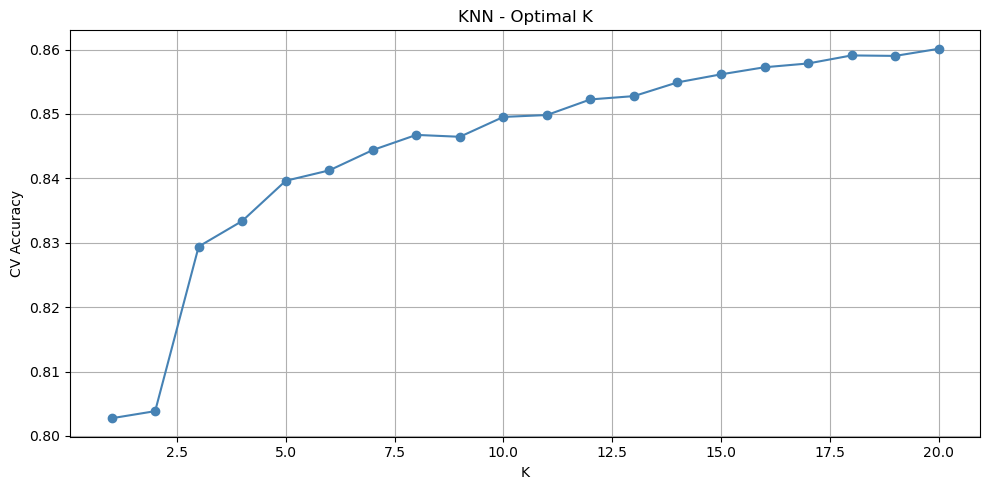

In [29]:
# 5.4 - KNN + Optimal K
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn    = knn.predict(X_test)
train_acc_knn = knn.score(X_train, y_train)
test_acc_knn  = accuracy_score(y_test, y_pred_knn)
f1_knn        = f1_score(y_test, y_pred_knn, average='weighted')
cv_scores_knn = cross_val_score(knn, X_scaled, y, cv=5)

print('KNN')
print(f'Train: {train_acc_knn:.4f} | Test: {test_acc_knn:.4f} | F1: {f1_knn:.4f} | CV: {cv_scores_knn.mean():.4f}')
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

k_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_scaled, y, cv=5).mean() for k in range(1,21)]
plt.figure(figsize=(10, 5))
plt.plot(range(1,21), k_scores, marker='o', color='steelblue')
plt.title('KNN - Optimal K')
plt.xlabel('K')
plt.ylabel('CV Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
# 5.5 - SVM
svm = SVC(kernel='rbf', random_state=42, probability=True)
svm.fit(X_train, y_train)
y_pred_svm    = svm.predict(X_test)
train_acc_svm = svm.score(X_train, y_train)
test_acc_svm  = accuracy_score(y_test, y_pred_svm)
f1_svm        = f1_score(y_test, y_pred_svm, average='weighted')
cv_scores_svm = cross_val_score(svm, X_scaled, y, cv=5)

print('SVM')
print(f'Train: {train_acc_svm:.4f} | Test: {test_acc_svm:.4f} | F1: {f1_svm:.4f} | CV: {cv_scores_svm.mean():.4f}')
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

SVM
Train: 0.9342 | Test: 0.9254 | F1: 0.9254 | CV: 0.8465
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.91      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.95      0.95       326
    DERMASON       0.91      0.92      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.87      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [31]:
# 5.6 - Ensemble Methods
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb    = gb.predict(X_test)
train_acc_gb = gb.score(X_train, y_train)
test_acc_gb  = accuracy_score(y_test, y_pred_gb)
f1_gb        = f1_score(y_test, y_pred_gb, average='weighted')

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada    = ada.predict(X_test)
train_acc_ada = ada.score(X_train, y_train)
test_acc_ada  = accuracy_score(y_test, y_pred_ada)
f1_ada        = f1_score(y_test, y_pred_ada, average='weighted')

print('GRADIENT BOOSTING')
print(f'Train: {train_acc_gb:.4f} | Test: {test_acc_gb:.4f} | F1: {f1_gb:.4f}')
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))
print('ADABOOST')
print(f'Train: {train_acc_ada:.4f} | Test: {test_acc_ada:.4f} | F1: {f1_ada:.4f}')
print(classification_report(y_test, y_pred_ada, target_names=le.classes_))

GRADIENT BOOSTING
Train: 0.9628 | Test: 0.9221 | F1: 0.9221
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.90      0.93      0.91       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.95      0.96      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

ADABOOST
Train: 0.8369 | Test: 0.8256 | F1: 0.8114
              precision    recall  f1-score   support

    BARBUNYA       0.89      0.56      0.69       265
      BOMBAY       0.00      0.00      0.00       104
        CALI       0.58      0.96      0.72       326
    DERMASON       0.83      0.94      0.88       709
       HOROZ       0.

In [32]:
# 5.7 - Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb    = gnb.predict(X_test)
train_acc_gnb = gnb.score(X_train, y_train)
test_acc_gnb  = accuracy_score(y_test, y_pred_gnb)
f1_gnb        = f1_score(y_test, y_pred_gnb, average='weighted')
cv_scores_gnb = cross_val_score(gnb, X_scaled, y, cv=5)

print('NAIVE BAYES')
print(f'Train: {train_acc_gnb:.4f} | Test: {test_acc_gnb:.4f} | F1: {f1_gnb:.4f} | CV: {cv_scores_gnb.mean():.4f}')
print(classification_report(y_test, y_pred_gnb, target_names=le.classes_))

NAIVE BAYES
Train: 0.8971 | Test: 0.8990 | F1: 0.8992 | CV: 0.8408
              precision    recall  f1-score   support

    BARBUNYA       0.91      0.79      0.85       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.87      0.93      0.90       326
    DERMASON       0.93      0.86      0.89       709
       HOROZ       0.95      0.95      0.95       386
       SEKER       0.93      0.94      0.94       406
        SIRA       0.80      0.90      0.85       527

    accuracy                           0.90      2723
   macro avg       0.91      0.91      0.91      2723
weighted avg       0.90      0.90      0.90      2723



---
## Step 6: Handling Class Imbalance

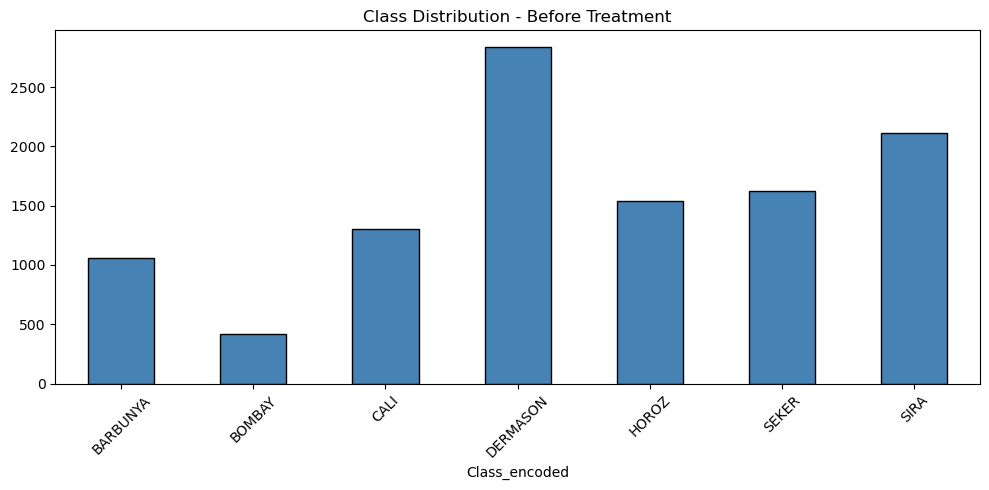

In [33]:
# 6.1 - Class Distribution Before
plt.figure(figsize=(10, 5))
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xticks(ticks=range(7), labels=le.classes_, rotation=45)
plt.title('Class Distribution - Before Treatment')
plt.tight_layout()
plt.show()

In [34]:
# 6.2 - SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)
print(f'RF + SMOTE -> Test: {accuracy_score(y_test, y_pred_smote):.4f}')
print(classification_report(y_test, y_pred_smote, target_names=le.classes_))

RF + SMOTE -> Test: 0.9207
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.91      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.93      0.94       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.93      0.97      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [35]:
# 6.3 - Oversampling & Undersampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
rf_ros = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ros.fit(X_train_ros, y_train_ros)
y_pred_ros = rf_ros.predict(X_test)
print(f'RF + Oversampling -> Test: {accuracy_score(y_test, y_pred_ros):.4f}')

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
rf_rus = RandomForestClassifier(n_estimators=100, random_state=42)
rf_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = rf_rus.predict(X_test)
print(f'RF + Undersampling -> Test: {accuracy_score(y_test, y_pred_rus):.4f}')

RF + Oversampling -> Test: 0.9196
RF + Undersampling -> Test: 0.9133


In [36]:
# 6.4 - Class Weighting
rf_cw = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_cw.fit(X_train, y_train)
y_pred_cw = rf_cw.predict(X_test)
print(f'RF + Class Weighting -> Test: {accuracy_score(y_test, y_pred_cw):.4f}')

RF + Class Weighting -> Test: 0.9196


In [37]:
# 6.5 - Minority Class Comparison
models_imb = {
    'RF (No Treatment)' : rf,
    'RF + SMOTE'        : rf_smote,
    'RF + Oversampling' : rf_ros,
    'RF + Undersampling': rf_rus,
    'RF + Class Weight' : rf_cw
}
results = []
for name, model in models_imb.items():
    yp     = model.predict(X_test)
    report = classification_report(y_test, yp, target_names=le.classes_, output_dict=True)
    results.append({'Model': name,
                    'Overall Accuracy': round(accuracy_score(y_test, yp), 4),
                    'BOMBAY Recall': round(report['BOMBAY']['recall'], 4),
                    'BOMBAY F1': round(report['BOMBAY']['f1-score'], 4)})
print(pd.DataFrame(results).to_string(index=False))

             Model  Overall Accuracy  BOMBAY Recall  BOMBAY F1
 RF (No Treatment)            0.9225            1.0        1.0
        RF + SMOTE            0.9207            1.0        1.0
 RF + Oversampling            0.9196            1.0        1.0
RF + Undersampling            0.9133            1.0        1.0
 RF + Class Weight            0.9196            1.0        1.0


---
## Step 7: Model Evaluation & Overfitting Check

In [38]:
# 7.1 - All Model Metrics
models_eval = {
    'Logistic Regression': (lr, y_pred_lr),
    'Decision Tree'      : (dt, y_pred_dt),
    'Random Forest'      : (rf, y_pred_rf),
    'KNN'                : (knn, y_pred_knn),
    'SVM'                : (svm, y_pred_svm),
    'Gradient Boosting'  : (gb, y_pred_gb),
    'AdaBoost'           : (ada, y_pred_ada),
    'Naive Bayes'        : (gnb, y_pred_gnb)
}
print(f"{'Model':<25} {'Train':>8} {'Test':>8} {'F1':>8}")
print('-'*55)
for name, (model, yp) in models_eval.items():
    print(f"{name:<25} {model.score(X_train,y_train):>8.4f} {accuracy_score(y_test,yp):>8.4f} {f1_score(y_test,yp,average='weighted'):>8.4f}")

Model                        Train     Test       F1
-------------------------------------------------------
Logistic Regression         0.9259   0.9247   0.9248
Decision Tree               1.0000   0.8931   0.8928
Random Forest               1.0000   0.9225   0.9225
KNN                         0.9422   0.9144   0.9145
SVM                         0.9342   0.9254   0.9254
Gradient Boosting           0.9628   0.9221   0.9221
AdaBoost                    0.8369   0.8256   0.8114
Naive Bayes                 0.8971   0.8990   0.8992


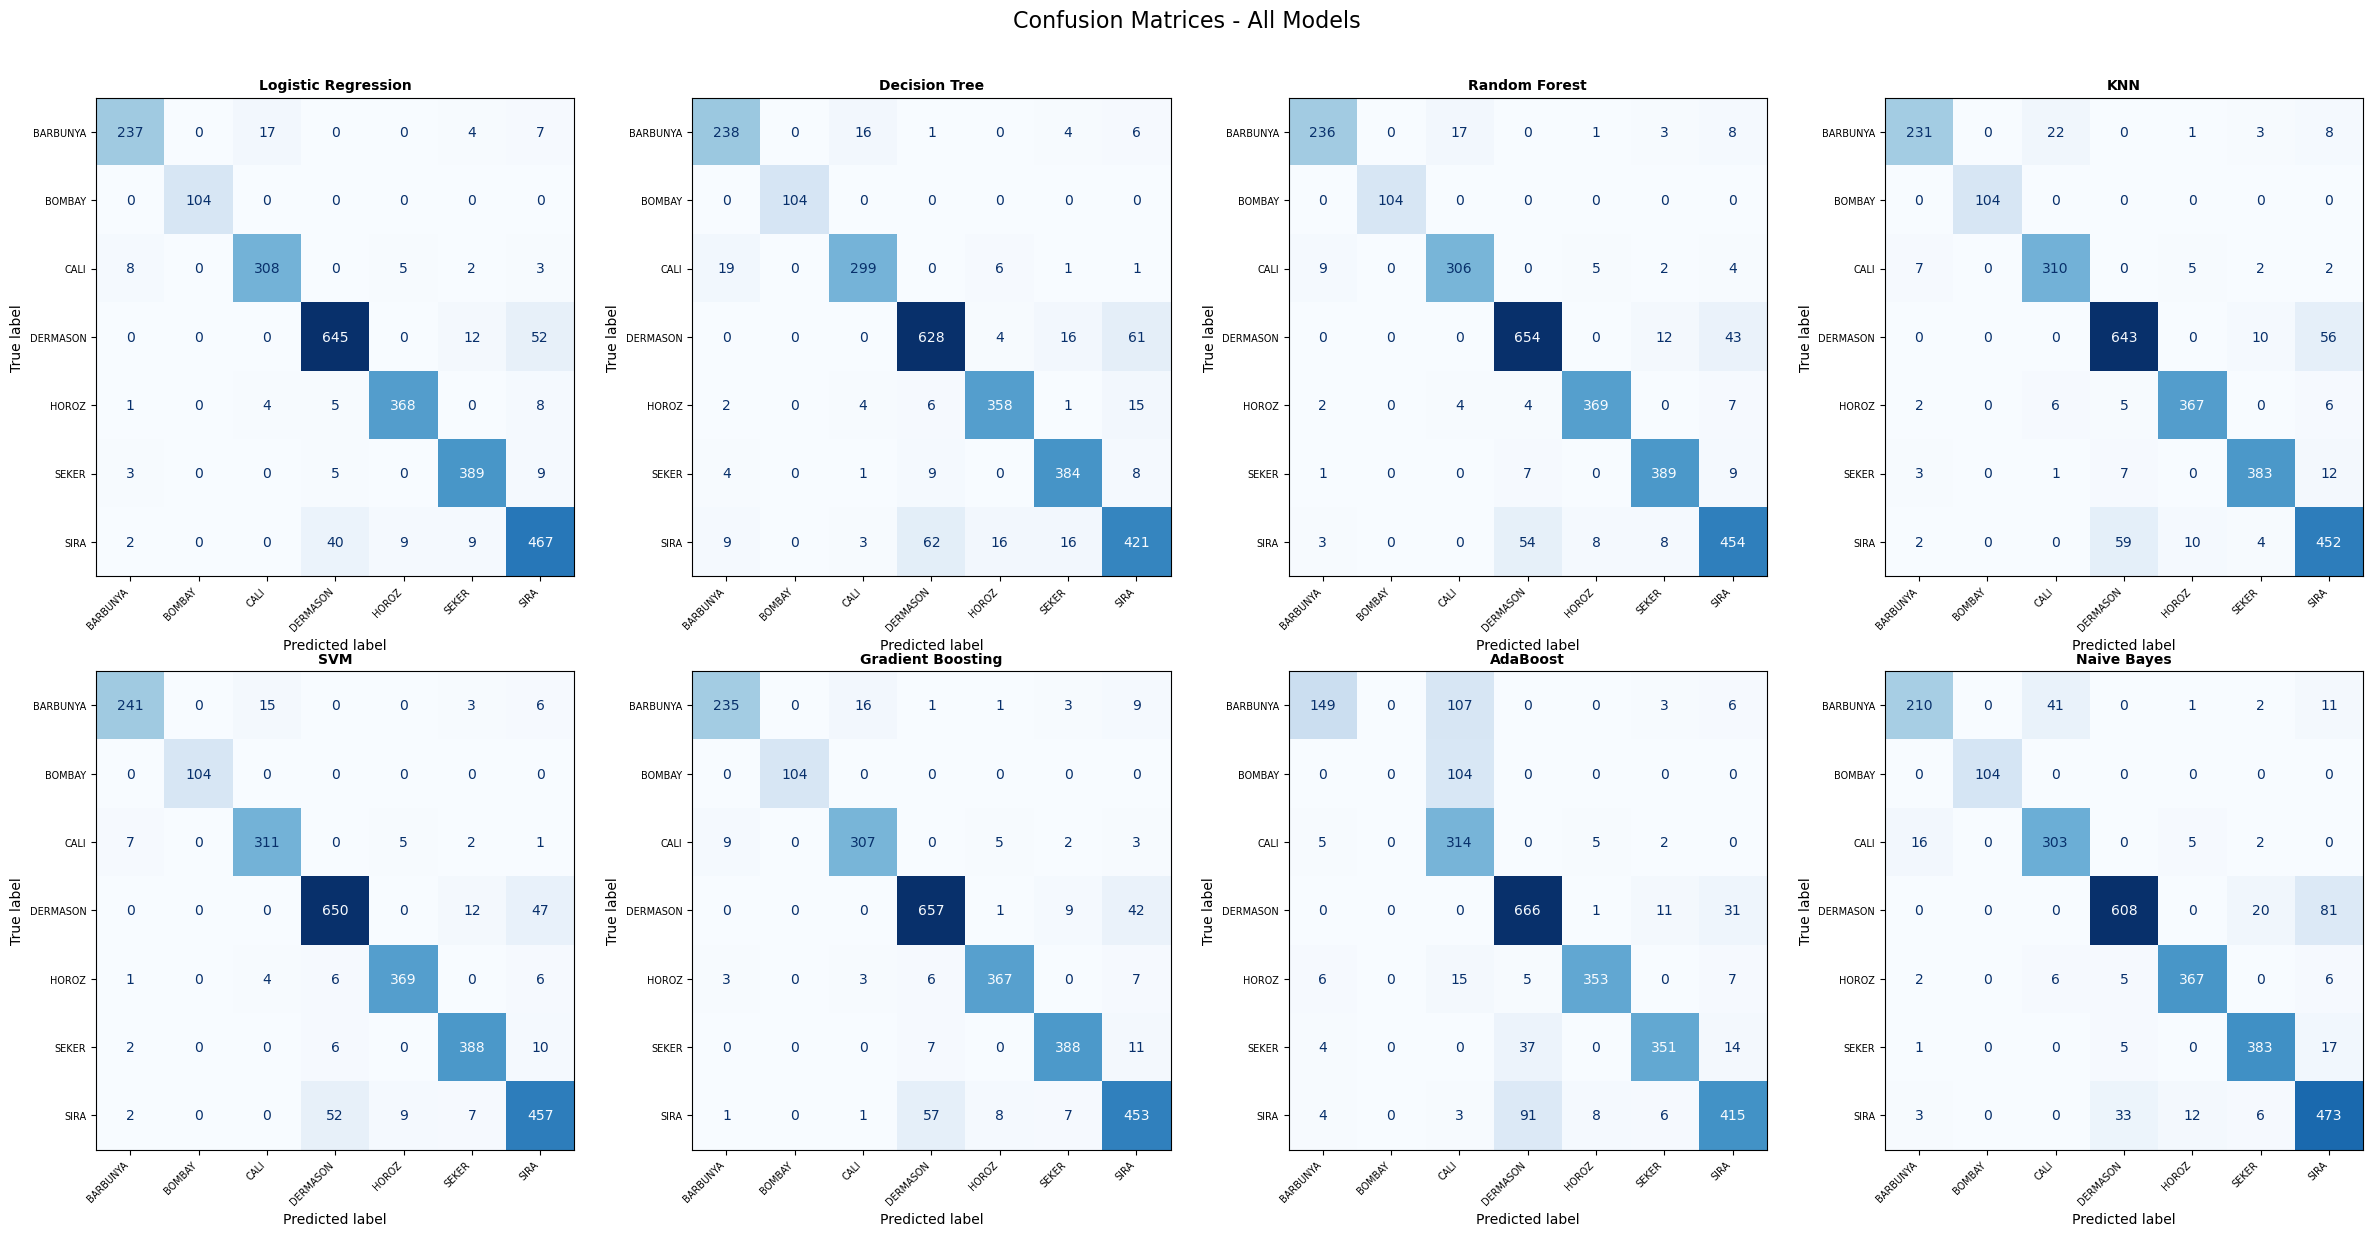

In [39]:
# 7.2 - Confusion Matrices
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.ravel()
for idx, (name, (model, yp)) in enumerate(models_eval.items()):
    cm   = confusion_matrix(y_test, yp)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name, fontsize=10, fontweight='bold')
    axes[idx].set_xticklabels(le.classes_, rotation=45, ha='right', fontsize=7)
    axes[idx].set_yticklabels(le.classes_, fontsize=7)
plt.suptitle('Confusion Matrices - All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Model                        Train     Test      Gap   Overfit?
-----------------------------------------------------------------
Logistic Regression         0.9259   0.9247   0.0012         NO
Decision Tree               1.0000   0.8931   0.1069        YES
Random Forest               1.0000   0.9225   0.0775        YES
KNN                         0.9422   0.9144   0.0278         NO
SVM                         0.9342   0.9254   0.0088         NO
Gradient Boosting           0.9628   0.9221   0.0407         NO
AdaBoost                    0.8369   0.8256   0.0113         NO
Naive Bayes                 0.8971   0.8990  -0.0019         NO


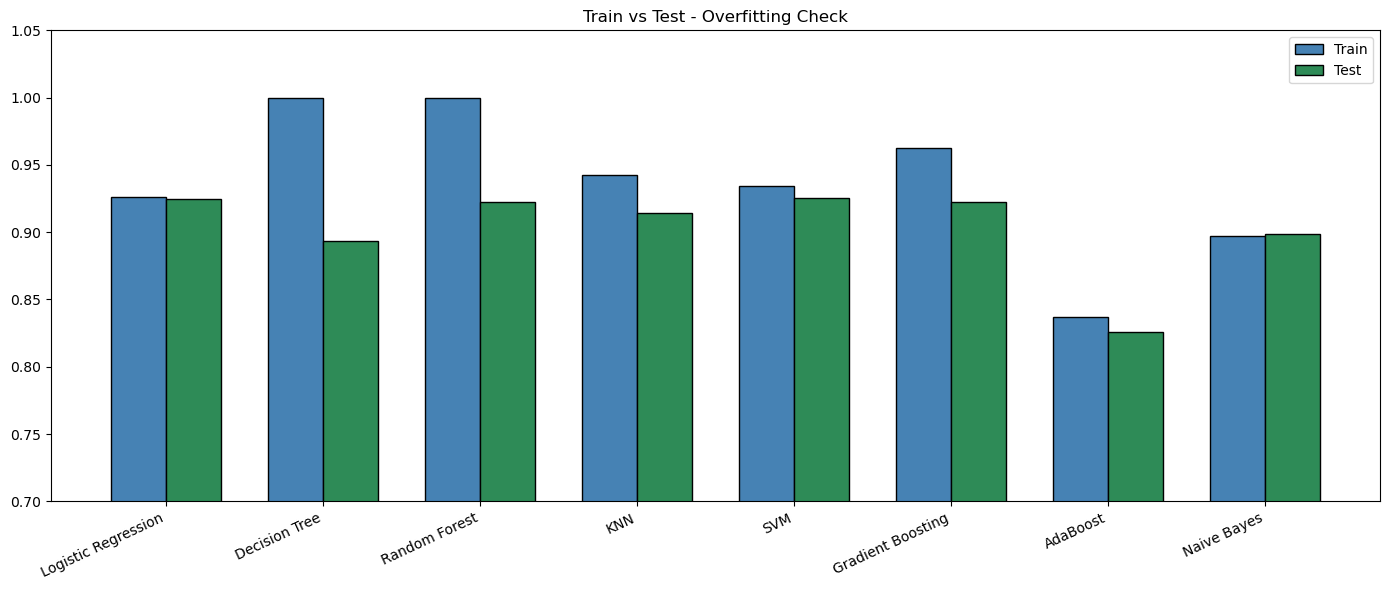

In [40]:
# 7.3 - Overfitting Check
print(f"{'Model':<25} {'Train':>8} {'Test':>8} {'Gap':>8} {'Overfit?':>10}")
print('-'*65)
of_data = []
for name, (model, yp) in models_eval.items():
    tr  = model.score(X_train, y_train)
    te  = accuracy_score(y_test, yp)
    gap = tr - te
    ovf = 'YES' if gap > 0.05 else 'NO'
    print(f"{name:<25} {tr:>8.4f} {te:>8.4f} {gap:>8.4f} {ovf:>10}")
    of_data.append({'Model': name, 'Train': round(tr,4), 'Test': round(te,4), 'Gap': round(gap,4), 'Overfit': ovf})

of_df = pd.DataFrame(of_data)
x = range(len(of_df))
width = 0.35
plt.figure(figsize=(14, 6))
plt.bar([i-width/2 for i in x], of_df['Train'], width, label='Train', color='steelblue', edgecolor='black')
plt.bar([i+width/2 for i in x], of_df['Test'],  width, label='Test',  color='seagreen',  edgecolor='black')
plt.xticks(x, of_df['Model'], rotation=25, ha='right')
plt.title('Train vs Test - Overfitting Check')
plt.legend()
plt.ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

---
## Step 8: Hyperparameter Tuning

In [41]:
# 8.1 - Random Forest (RandomizedSearchCV)
rf_param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2']
}
rf_random = RandomizedSearchCV(RandomForestClassifier(random_state=42),
    rf_param_grid, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1, verbose=1)
rf_random.fit(X_train, y_train)
y_pred_rf_tuned = rf_random.best_estimator_.predict(X_test)
print(f'RF Best Params : {rf_random.best_params_}')
print(f'Before: {test_acc_rf:.4f} | After: {accuracy_score(y_test, y_pred_rf_tuned):.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RF Best Params : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Before: 0.9225 | After: 0.9192


In [42]:
# 8.2 - SVM (GridSearchCV)
svm_param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'gamma'  : ['scale', 'auto', 0.01, 0.001],
    'kernel' : ['rbf', 'poly']
}
svm_grid = GridSearchCV(SVC(random_state=42, probability=True),
    svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
svm_grid.fit(X_train, y_train)
y_pred_svm_tuned = svm_grid.best_estimator_.predict(X_test)
print(f'SVM Best Params : {svm_grid.best_params_}')
print(f'Before: {test_acc_svm:.4f} | After: {accuracy_score(y_test, y_pred_svm_tuned):.4f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits
SVM Best Params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Before: 0.9254 | After: 0.9258


In [43]:
# 8.3 - KNN (GridSearchCV)
knn_param_grid = {
    'n_neighbors' : [3, 5, 7, 9, 11],
    'weights'     : ['uniform', 'distance'],
    'metric'      : ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(),
    knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid.fit(X_train, y_train)
y_pred_knn_tuned = knn_grid.best_estimator_.predict(X_test)
print(f'KNN Best Params : {knn_grid.best_params_}')
print(f'Before: {test_acc_knn:.4f} | After: {accuracy_score(y_test, y_pred_knn_tuned):.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
KNN Best Params : {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
Before: 0.9144 | After: 0.9199


In [44]:
# 8.4 - Tuning Summary
before = {'Random Forest': test_acc_rf, 'SVM': test_acc_svm, 'KNN': test_acc_knn}
after  = {
    'Random Forest': accuracy_score(y_test, y_pred_rf_tuned),
    'SVM'          : accuracy_score(y_test, y_pred_svm_tuned),
    'KNN'          : accuracy_score(y_test, y_pred_knn_tuned)
}
best_p = {'Random Forest': rf_random.best_params_, 'SVM': svm_grid.best_params_, 'KNN': knn_grid.best_params_}

print('HYPERPARAMETER TUNING - SUMMARY')
for m in before:
    imp = (after[m] - before[m]) * 100
    d   = '+' if imp >= 0 else ''
    print(f'\n {m}')
    print(f'   Best Params : {best_p[m]}')
    print(f'   Before      : {before[m]:.4f}')
    print(f'   After       : {after[m]:.4f}')
    print(f'   Improvement : {d}{imp:.2f}%')

HYPERPARAMETER TUNING - SUMMARY

 Random Forest
   Best Params : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
   Before      : 0.9225
   After       : 0.9192
   Improvement : -0.33%

 SVM
   Best Params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
   Before      : 0.9254
   After       : 0.9258
   Improvement : +0.04%

 KNN
   Best Params : {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
   Before      : 0.9144
   After       : 0.9199
   Improvement : +0.55%


---
## Step 9: Model Comparison Table

In [45]:
comparison_data = {
    'Model': ['Logistic Regression','Decision Tree','Random Forest',
              'SVM','KNN','Gradient Boosting','AdaBoost','Naive Bayes'],
    'Train Accuracy': [
        round(lr.score(X_train, y_train), 4),
        round(dt.score(X_train, y_train), 4),
        round(rf.score(X_train, y_train), 4),
        round(svm_grid.best_estimator_.score(X_train, y_train), 4),
        round(knn_grid.best_estimator_.score(X_train, y_train), 4),
        round(gb.score(X_train, y_train), 4),
        round(ada.score(X_train, y_train), 4),
        round(gnb.score(X_train, y_train), 4)
    ],
    'Test Accuracy': [
        round(test_acc_lr, 4), round(test_acc_dt, 4), round(test_acc_rf, 4),
        round(accuracy_score(y_test, y_pred_svm_tuned), 4),
        round(accuracy_score(y_test, y_pred_knn_tuned), 4),
        round(test_acc_gb, 4), round(test_acc_ada, 4), round(test_acc_gnb, 4)
    ],
    'F1 Score': [
        round(f1_lr, 4), round(f1_dt, 4), round(f1_rf, 4),
        round(f1_score(y_test, y_pred_svm_tuned, average='weighted'), 4),
        round(f1_score(y_test, y_pred_knn_tuned, average='weighted'), 4),
        round(f1_gb, 4), round(f1_ada, 4), round(f1_gnb, 4)
    ],
    'Overfitting': [
        'Yes' if lr.score(X_train,y_train)-test_acc_lr > 0.05 else 'No',
        'Yes' if dt.score(X_train,y_train)-test_acc_dt > 0.05 else 'No',
        'Yes' if rf.score(X_train,y_train)-test_acc_rf > 0.05 else 'No',
        'Yes' if svm_grid.best_estimator_.score(X_train,y_train)-accuracy_score(y_test,y_pred_svm_tuned) > 0.05 else 'No',
        'Yes' if knn_grid.best_estimator_.score(X_train,y_train)-accuracy_score(y_test,y_pred_knn_tuned) > 0.05 else 'No',
        'Yes' if gb.score(X_train,y_train)-test_acc_gb > 0.05 else 'No',
        'Yes' if ada.score(X_train,y_train)-test_acc_ada > 0.05 else 'No',
        'Yes' if gnb.score(X_train,y_train)-test_acc_gnb > 0.05 else 'No'
    ]
}

comparison_df = pd.DataFrame(comparison_data).sort_values('Test Accuracy', ascending=False)
print('='*75)
print('                  MODEL COMPARISON TABLE')
print('='*75)
print(comparison_df.to_string(index=False))
print('='*75)
best = comparison_df.iloc[0]
print(f'\nBEST MODEL: {best["Model"]} | Test Acc: {best["Test Accuracy"]} | F1: {best["F1 Score"]} | Overfit: {best["Overfitting"]}')

                  MODEL COMPARISON TABLE
              Model  Train Accuracy  Test Accuracy  F1 Score Overfitting
                SVM          0.9400         0.9258    0.9257          No
Logistic Regression          0.9259         0.9247    0.9248          No
      Random Forest          1.0000         0.9225    0.9225         Yes
  Gradient Boosting          0.9628         0.9221    0.9221          No
                KNN          1.0000         0.9199    0.9200         Yes
        Naive Bayes          0.8971         0.8990    0.8992          No
      Decision Tree          1.0000         0.8931    0.8928         Yes
           AdaBoost          0.8369         0.8256    0.8114          No

BEST MODEL: SVM | Test Acc: 0.9258 | F1: 0.9257 | Overfit: No


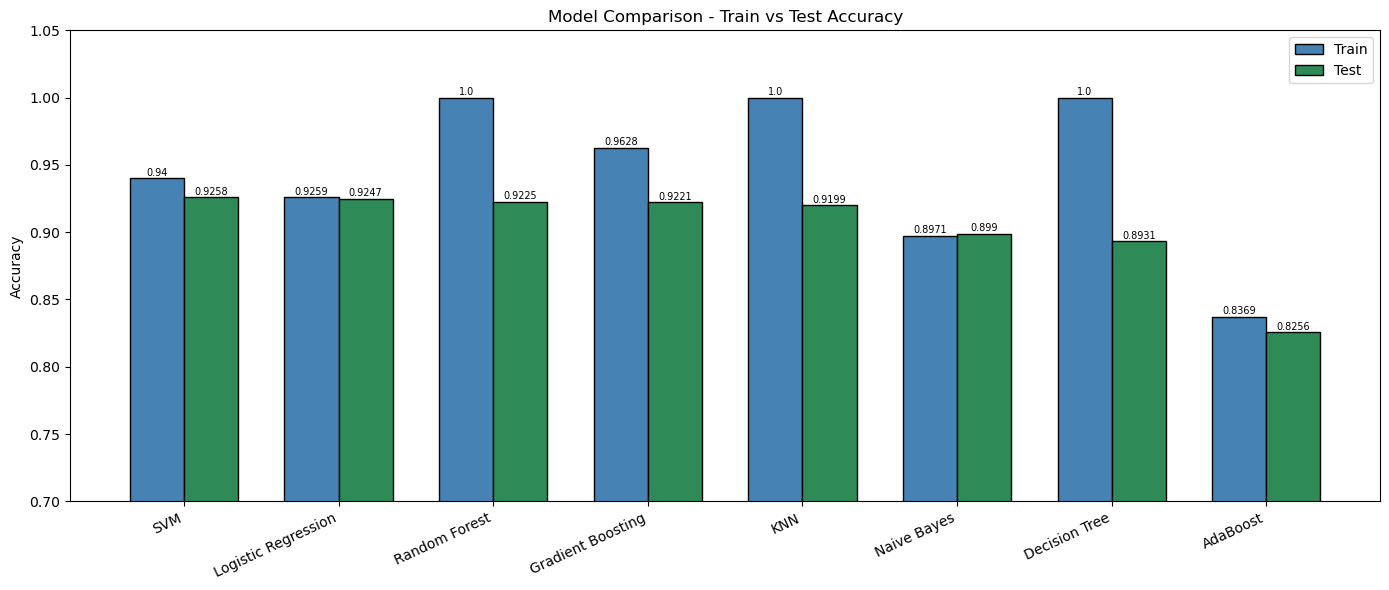

In [46]:
# Visualization
x = range(len(comparison_df))
w = 0.35
plt.figure(figsize=(14, 6))
plt.bar([i-w/2 for i in x], comparison_df['Train Accuracy'], w, label='Train', color='steelblue', edgecolor='black')
plt.bar([i+w/2 for i in x], comparison_df['Test Accuracy'],  w, label='Test',  color='seagreen',  edgecolor='black')
for i,(tr,te) in enumerate(zip(comparison_df['Train Accuracy'],comparison_df['Test Accuracy'])):
    plt.text(i-w/2, tr+0.002, str(tr), ha='center', fontsize=7)
    plt.text(i+w/2, te+0.002, str(te), ha='center', fontsize=7)
plt.xticks(x, comparison_df['Model'], rotation=25, ha='right')
plt.ylabel('Accuracy')
plt.title('Model Comparison - Train vs Test Accuracy')
plt.legend()
plt.ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

---
## Step 10: Streamlit App - Bean Classifier

In [47]:
import joblib, os

joblib.dump(svm_grid.best_estimator_, 'bean_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print('Models saved!')
print(f'Model  : {os.path.getsize("bean_model.pkl")/1024:.1f} KB')
print(f'Scaler : {os.path.getsize("scaler.pkl")/1024:.1f} KB')
print(f'Encoder: {os.path.getsize("label_encoder.pkl")/1024:.1f} KB')

Models saved!
Model  : 425.9 KB
Scaler : 1.5 KB
Encoder: 0.6 KB


**App Link :** https://bean-classifier-app-byvineeth.streamlit.app/

**GitHub   :** https://github.com/Vineeth-Muraleedharan/Bean-classifier